# BOQ Retrieval Evaluation — Base vs Fine-Tuned Model
## FAISS-Powered Document-to-Document Retrieval with Full Metrics Report

**What this notebook does:**
1. Uploads your test BOQ PDFs (fresh, not seen during training)
2. Extracts text with the same OCR pipeline used in training
3. Builds content-driven TF-IDF smart anchors (no filenames, no hardcoding)
4. Encodes with **Base Qwen3-Embedding-0.6B** → stores in FAISS
5. Encodes with your **Fine-Tuned model** → stores in FAISS
6. Builds content-based ground truth via agglomerative clustering
7. Runs every query against both FAISS indices → Top-10 retrieval
8. Computes: **P@K · R@K · F1@K · MRR · MAP · NDCG@K · Hit@K · Cosine-sim · Silhouette**
9. Side-by-side comparison report + bar charts
10. Single-query demo: upload any BOQ PDF and see Top-10 from both models

> **Paths are auto-read from `DRIVE_BASE` — no hardcoding.**


In [1]:
# ================================================================
# CELL 1 — Mount Google Drive
# ================================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
import os
print("Drive mounted.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


In [3]:
# ================================================================
# CELL 2 — Install / upgrade all required packages
#           (faiss-cpu added for vector store)
# ================================================================
import subprocess, sys

def pip(*args):
    subprocess.run([sys.executable, "-m", "pip"] + list(args),
                   check=True, capture_output=True)

pkgs = [
    "sentence-transformers>=3.3.0",
    "transformers>=4.51.0",
    "accelerate>=0.30.0",
    "pdfplumber>=0.10.0",
    "pymupdf>=1.23.0",
    "easyocr",
    "pdf2image",
    "scikit-learn>=1.3.0",
    "faiss-cpu",          # FAISS vector store
    "tqdm",
    "matplotlib",
    "seaborn",
    "numpy",
    "scipy",
]
print("Installing packages ...")
for p in pkgs:
    print(f"  {p}", end=" ", flush=True)
    pip("install", "-U", "-q", p)
    print("✓")

subprocess.run(["apt-get", "update",  "-qq"], check=False, capture_output=True)
subprocess.run(["apt-get", "install", "-y", "-q", "poppler-utils"],
               check=False, capture_output=True)
print("\n✅ All packages installed.")
print("If FIRST RUN → Runtime > Restart runtime, then run from Cell 1.")


Installing packages ...
  sentence-transformers>=3.3.0 ✓
  transformers>=4.51.0 ✓
  accelerate>=0.30.0 ✓
  pdfplumber>=0.10.0 ✓
  pymupdf>=1.23.0 ✓
  easyocr ✓
  pdf2image ✓
  scikit-learn>=1.3.0 ✓
  faiss-cpu ✓
  tqdm ✓
  matplotlib ✓
  seaborn ✓
  numpy ✓
  scipy ✓

✅ All packages installed.
If FIRST RUN → Runtime > Restart runtime, then run from Cell 1.


In [2]:
# ================================================================
# CELL 3 — Configuration  ← EDIT DRIVE_BASE if your path differs
# ================================================================
from pathlib import Path

# ── Model paths (match your training notebook) ──────────────────
BASE_MODEL_NAME = "Qwen/Qwen3-Embedding-0.6B"
DRIVE_BASE      = "/content/drive/MyDrive/BOQ_FineTune_Neww"
FT_MODEL_DIR    = f"{DRIVE_BASE}/best_model"

# ── Output directories ──────────────────────────────────────────
EVAL_DIR  = Path(f"{DRIVE_BASE}/eval_results")
FAISS_DIR = Path(f"{DRIVE_BASE}/faiss_indices")
for d in (EVAL_DIR, FAISS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ── Qwen3 asymmetric retrieval instruction ──────────────────────
# Must match exactly what was used during training
QUERY_INSTRUCTION = (
    "Instruct: Given a Bill of Quantities (BOQ) document from the construction "
    "domain, retrieve the most semantically similar BOQ documents that describe "
    "the same type of construction project.\nQuery: "
)

# ── Text / anchor settings (must mirror training notebook) ──────
MAX_SEQ_LEN      = 1024
MAX_ANCHOR_CHARS = 2000
MIN_DESC_LEN     = 10
MAX_DF           = 0.35   # critical: keeps generic tokens (cement/plaster) out
MIN_DF           = 1      # raise to 2 if you have 20+ test docs

# ── Ground-truth clustering ─────────────────────────────────────
SIMILARITY_THRESHOLD = 0.70   # cosine threshold for same-group
MIN_CLUSTER_SIZE     = 2      # singletons skipped in IR metrics

# ── Evaluation Ks ───────────────────────────────────────────────
TOP_K_LIST = [1, 3, 5, 10]

print("Configuration loaded.")
print(f"  Base model      : {BASE_MODEL_NAME}")
print(f"  Fine-tuned dir  : {FT_MODEL_DIR}")

print(f"  FT model exists : {Path(FT_MODEL_DIR).exists()}")
print(f"  Eval dir        : {EVAL_DIR}")
print(f"  FAISS dir       : {FAISS_DIR}")


Configuration loaded.
  Base model      : Qwen/Qwen3-Embedding-0.6B
  Fine-tuned dir  : /content/drive/MyDrive/BOQ_FineTune_Neww/best_model
  FT model exists : True
  Eval dir        : /content/drive/MyDrive/BOQ_FineTune_Neww/eval_results
  FAISS dir       : /content/drive/MyDrive/BOQ_FineTune_Neww/faiss_indices


In [3]:
# ================================================================
# CELL 4 — Upload Test BOQ PDFs
#           Upload a ZIP or individual PDFs (held-out from training)
# ================================================================
from google.colab import files as colab_files
from pathlib import Path
import zipfile

TEST_PDF_DIR = Path("/content/test_boq_pdfs")
TEST_PDF_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 62)
print("Upload your test BOQ PDFs (ZIP or individual .pdf files).")
print("Use PDFs that were NOT in the training set for clean eval.")
print("=" * 62)
uploaded = colab_files.upload()

if not uploaded:
    raise ValueError("No files uploaded. Please upload at least 2 BOQ PDFs.")

for fname, data in uploaded.items():
    dest = TEST_PDF_DIR / fname
    dest.write_bytes(data)
    if fname.lower().endswith(".zip"):
        print(f"  Extracting {fname} ...")
        with zipfile.ZipFile(str(dest), "r") as z:
            z.extractall(TEST_PDF_DIR)
        dest.unlink()

pdf_files = sorted(
    list(TEST_PDF_DIR.rglob("*.pdf")) + list(TEST_PDF_DIR.rglob("*.PDF"))
)
print(f"\n{len(pdf_files)} PDFs found:")
for p in pdf_files[:20]:
    print(f"   {p.name:<55} ({p.stat().st_size/1024:.1f} KB)")
if len(pdf_files) > 20:
    print(f"   ... and {len(pdf_files)-20} more")

assert len(pdf_files) >= 2, "Need at least 2 test PDFs for evaluation."


Upload your test BOQ PDFs (ZIP or individual .pdf files).
Use PDFs that were NOT in the training set for clean eval.


Saving Boq_Tr.zip to Boq_Tr.zip
  Extracting Boq_Tr.zip ...

469 PDFs found:
   BOQ_01681_Water_Treatment_Plant.pdf                     (33.4 KB)
   BOQ_03161_Commercial_Office_Complex.pdf                 (40.9 KB)
   BOQ_0431_Affordable_Housing_Scheme.pdf                  (30.8 KB)
   BOQ_0431_Cable-Stayed_Bridge_Project.pdf                (39.7 KB)
   BOQ_0432_Hospital_&_Healthcare_Facility.pdf             (28.1 KB)
   BOQ_0432_Riverfront_Retaining_Works.pdf                 (36.6 KB)
   BOQ_0433_Fire_and_Emergency_Services_.pdf               (38.4 KB)
   BOQ_0433_Government_Administrative_Bloc.pdf             (28.8 KB)
   BOQ_0434_School_Expansion_Program.pdf                   (38.5 KB)
   BOQ_0434_Solar_Farm_Installation.pdf                    (20.6 KB)
   BOQ_0435_Metro_Rail_Station.pdf                         (22.7 KB)
   BOQ_0435_Residential_Villa_Cluster.pdf                  (37.0 KB)
   BOQ_0436_Sewage_Treatment_Facility.pdf                  (22.7 KB)
   BOQ_0436_Sewage_Treatme

In [4]:
# ================================================================
# CELL 5 — OCR Pipeline + BOQ Description Extractor
#           Identical logic to training notebook:
#           pdfplumber → PyMuPDF → EasyOCR (cascade)
# ================================================================
import re, gc
import numpy as np
import pdfplumber
import fitz   # PyMuPDF
import torch
from pathlib import Path
from typing import List, Dict
from tqdm.auto import tqdm

# ── Skip-pattern: strip BOQ header / footer boilerplate ────────
_SKIP_PAT = re.compile(
    r'^(s\.?no\.?|sr\.?\s*no\.?|description|unit|qty|quantity|'
    r'rate|amount|sub[-\s]?total|^total\b|^grand[-\s]?total\b|'
    r'bill\s+of\s+quantities|client\s*:|location\s*:|'
    r'project\s*:|ref\s*:|currency\s*:|page\s*\d)',
    re.IGNORECASE
)

# ── Extraction back-ends ────────────────────────────────────────
def extract_pdfplumber(pdf_path: str) -> List[Dict]:
    pages = []
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for i, page in enumerate(pdf.pages):
                text = page.extract_text(x_tolerance=3, y_tolerance=3) or ""
                if len(text.strip()) < 100:
                    tables = page.extract_tables(
                        {"vertical_strategy": "lines_strict",
                         "horizontal_strategy": "lines_strict"}) or []
                    rows = []
                    for tbl in tables:
                        for row in (tbl or []):
                            cells = [str(c or "").strip() for c in (row or [])]
                            line  = "  ".join(c for c in cells if c)
                            if line: rows.append(line)
                    if rows: text = "\n".join(rows)
                if text.strip():
                    pages.append({"page": i+1, "text": text.strip()})
    except Exception:
        pass
    return pages

def extract_pymupdf(pdf_path: str) -> List[Dict]:
    pages = []
    try:
        doc = fitz.open(pdf_path)
        for i, page in enumerate(doc):
            blocks = page.get_text("blocks", sort=True)
            texts  = [b[4].strip() for b in blocks if isinstance(b[4], str) and b[4].strip()]
            text   = "\n".join(texts)
            if text: pages.append({"page": i+1, "text": text})
        doc.close()
    except Exception:
        pass
    return pages

def extract_easyocr(pdf_path: str) -> List[Dict]:
    pages = []
    try:
        import easyocr
        from pdf2image import convert_from_path
        if not hasattr(extract_easyocr, "_reader"):
            print("    Initialising EasyOCR (one-time, ~30 s) ...")
            extract_easyocr._reader = easyocr.Reader(
                ["en"], gpu=torch.cuda.is_available(), verbose=False)
        images = convert_from_path(pdf_path, dpi=200)
        for i, img in enumerate(images):
            result = extract_easyocr._reader.readtext(
                np.array(img), detail=0, paragraph=True)
            text = "\n".join(str(r) for r in result)
            if text.strip(): pages.append({"page": i+1, "text": text.strip()})
    except Exception as e:
        print(f"    EasyOCR error: {e}")
    return pages

def _total_chars(pages): return sum(len(p.get("text", "")) for p in pages)

def smart_extract(pdf_path: str, verbose: bool = False) -> str:
    """Cascade: pdfplumber → PyMuPDF → EasyOCR. Returns full raw text."""
    for name, fn in (("pdfplumber", extract_pdfplumber),
                     ("PyMuPDF",    extract_pymupdf),
                     ("EasyOCR",    extract_easyocr)):
        pages = fn(pdf_path)
        chars = _total_chars(pages)
        if verbose:
            print(f"  [{name}] {len(pages)} pages, {chars} chars")
        if chars >= 200:
            if verbose: print(f"  Using {name}")
            return "\n".join(p["text"] for p in pages)
    return ""

# ── BOQ description line extractor ─────────────────────────────
def extract_boq_descriptions(raw_text: str) -> List[str]:
    """
    Pull substantive description lines from BOQ text.
    Drops: header rows, pure-numeric lines, very short lines.
    Content-only — no hardcoded keywords or filenames.
    """
    lines = []
    for line in raw_text.splitlines():
        line = line.strip()
        if len(line) < MIN_DESC_LEN:
            continue
        if _SKIP_PAT.match(line):
            continue
        # drop lines that are mostly digits/punctuation (qty/amount rows)
        alpha_ratio = sum(c.isalpha() for c in line) / max(len(line), 1)
        if alpha_ratio < 0.30:
            continue
        # drop lines with < 3 alphabetic tokens (likely reference codes)
        tokens = re.findall(r'[a-zA-Z]{2,}', line)
        if len(tokens) < 3:
            continue
        lines.append(line)
    return lines

def release_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("✅ OCR pipeline and BOQ extractor ready.")


✅ OCR pipeline and BOQ extractor ready.


In [5]:
# ================================================================
# CELL 6 — Extract Text From All Test PDFs
# ================================================================
doc_texts:        Dict[str, str]        = {}
doc_descriptions: Dict[str, List[str]]  = {}
failed_pdfs: List[str] = []

print(f"Extracting text from {len(pdf_files)} PDFs ...")
print("(Using cascade: pdfplumber → PyMuPDF → EasyOCR)\n")

for pdf_path in tqdm(pdf_files, desc="Extracting"):
    stem     = pdf_path.stem
    raw_text = smart_extract(str(pdf_path), verbose=False)

    if len(raw_text.strip()) < 50:
        print(f"  ⚠  Skipping {pdf_path.name} — no text extracted")
        failed_pdfs.append(str(pdf_path))
        continue

    descs = extract_boq_descriptions(raw_text)
    if not descs:
        print(f"  ⚠  Skipping {pdf_path.name} — no BOQ descriptions found")
        failed_pdfs.append(str(pdf_path))
        continue

    doc_texts[stem]        = raw_text
    doc_descriptions[stem] = descs

print(f"\n{'='*55}")
print(f"  Extracted : {len(doc_texts)} / {len(pdf_files)} PDFs")
if failed_pdfs:
    print(f"  Failed    : {len(failed_pdfs)} — "          + ", ".join(Path(f).name for f in failed_pdfs[:5]))
if doc_descriptions:
    counts = [len(d) for d in doc_descriptions.values()]
    print(f"  Desc lines: min={min(counts)}  avg={int(np.mean(counts))}  max={max(counts)}")
print(f"{'='*55}")

assert len(doc_texts) >= 2, (
    f"Only {len(doc_texts)} PDF(s) parsed successfully. "
    "Need ≥ 2 for evaluation.")


Extracting text from 469 PDFs ...
(Using cascade: pdfplumber → PyMuPDF → EasyOCR)



Extracting:   0%|          | 0/469 [00:00<?, ?it/s]


  Extracted : 469 / 469 PDFs
  Desc lines: min=116  avg=313  max=598


In [6]:
import numpy as np
import re
from typing import Dict, List
from sklearn.feature_extraction.text import TfidfVectorizer

# ================================================================
# CELL 7 — TF-IDF Keyword Extraction + Smart Anchor Builder
#           Content-driven only. No filenames. No hardcoded lists.
# ================================================================

stems_list = list(doc_descriptions.keys())
all_texts  = [" ".join(doc_descriptions[s]) for s in stems_list]

print(f"Fitting TF-IDF over {len(stems_list)} test documents ...")
print(f"  MAX_DF={MAX_DF}  MIN_DF={MIN_DF}  (keeps domain-specific tokens)")

tfidf = TfidfVectorizer(
    stop_words    = "english",
    max_features  = 20_000,
    max_df        = MAX_DF,
    min_df        = MIN_DF,
    token_pattern = r"(?u)\b(?=[a-zA-Z0-9]*[a-zA-Z])[a-zA-Z0-9]{3,}\b",
    sublinear_tf  = True,
)
tfidf_matrix  = tfidf.fit_transform(all_texts)
feature_names = tfidf.get_feature_names_out()
vocab_index   = {t: i for i, t in enumerate(feature_names)}
dense_matrix  = tfidf_matrix.toarray()
stem_to_row   = {s: dense_matrix[i] for i, s in enumerate(stems_list)}

doc_keywords: Dict[str, List[str]] = {}
doc_label:    Dict[str, str]       = {}

for stem in stems_list:
    row     = stem_to_row[stem]
    top_idx = np.argsort(-row)[:20]
    kws     = [feature_names[j] for j in top_idx if row[j] > 0]
    doc_keywords[stem] = kws
    doc_label[stem]    = " | ".join(kws[:4]) if kws else stem

def _line_score(line: str, row) -> float:
    score = 0.0
    for tok in re.findall(r"[a-zA-Z0-9]{3,}", line.lower()):
        j = vocab_index.get(tok)
        if j is not None:
            score += float(row[j])
    return score

def make_smart_anchor(stem: str,
                      descriptions: List[str],
                      row=None,
                      max_chars: int = None) -> str:
    """Rank description lines by TF-IDF weight, keep top chars."""
    max_chars = MAX_ANCHOR_CHARS if max_chars is None else max_chars
    if row is None:
        row = stem_to_row.get(stem)
    if row is None or not descriptions:
        return " ".join(descriptions)[:max_chars]
    scored = sorted(descriptions,
                    key=lambda l: _line_score(l, row), reverse=True)
    out, total = [], 0
    for line in scored:
        if total + len(line) + 1 > max_chars:
            break
        out.append(line)
        total += len(line) + 1
    return "\n".join(out) if out else " ".join(descriptions)[:max_chars]

doc_anchors = {s: make_smart_anchor(s, doc_descriptions[s]) for s in stems_list}

print(f"\nVocabulary size: {len(feature_names)} tokens")
print(f"Built {len(doc_anchors)} smart anchors")
avg_len = int(np.mean([len(a) for a in doc_anchors.values()]))
print(f"Avg anchor length: {avg_len} chars\n")
print("Sample content signatures (top-4 keywords per BOQ):")
for s in stems_list[:8]:
    print(f"  {s[:45]:<45}  →  {doc_label[s]}")
if len(stems_list) > 8:
    print(f"  ... and {len(stems_list)-8} more")

Fitting TF-IDF over 469 test documents ...
  MAX_DF=0.35  MIN_DF=1  (keeps domain-specific tokens)

Vocabulary size: 657 tokens
Built 469 smart anchors
Avg anchor length: 1951 chars

Sample content signatures (top-4 keywords per BOQ):
  BOQ_01681_Water_Treatment_Plant                →  pipes | invert | circuits | seasonal
  BOQ_03161_Commercial_Office_Complex            →  seasonal | floors | shutters | systems
  BOQ_0431_Affordable_Housing_Scheme             →  20m | 47mm | paint | m40
  BOQ_0431_Cable-Stayed_Bridge_Project           →  floors | circuits | 600x600 | gauges
  BOQ_0432_Hospital_&_Healthcare_Facility        →  230mm | section | m40 | coats
  BOQ_0432_Riverfront_Retaining_Works            →  floors | pipes | chilled | grout
  BOQ_0433_Fire_and_Emergency_Services_          →  floors | seasonal | e250 | shutters
  BOQ_0433_Government_Administrative_Bloc        →  substructure | ton | 600x600mm | schedule
  ... and 461 more


In [7]:
# ================================================================
# CELL 8 — Encode with BASE Model → Build & Save FAISS Indices
#           Asymmetric: corpus = no prefix | query = with instruction
# ================================================================
import faiss, time
from sentence_transformers import SentenceTransformer

def encode_safe(mdl, texts: List[str], start_batch: int = 16) -> np.ndarray:
    """Encode with automatic OOM-safe batch halving."""
    batch = start_batch
    while batch >= 1:
        try:
            return mdl.encode(
                texts, batch_size=batch, show_progress_bar=True,
                convert_to_numpy=True, normalize_embeddings=True
            )
        except torch.cuda.OutOfMemoryError:
            print(f"  OOM at batch={batch} → halving ...")
            release_gpu(); batch //= 2
    print("  Falling back to CPU, batch=2 ...")
    return mdl.encode(texts, batch_size=2, show_progress_bar=True,
                      convert_to_numpy=True, normalize_embeddings=True,
                      device="cpu")

def build_faiss_ip(embeddings: np.ndarray) -> faiss.IndexFlatIP:
    """Flat inner-product index (= cosine sim for L2-normalised vectors)."""
    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings.astype(np.float32))
    return index

corpus_texts = [doc_anchors[s] for s in stems_list]
query_texts  = [QUERY_INSTRUCTION + doc_anchors[s] for s in stems_list]

print(f"Loading BASE model: {BASE_MODEL_NAME} ...")
t0 = time.time()
base_model = SentenceTransformer(BASE_MODEL_NAME, trust_remote_code=True)
base_model.max_seq_length = MAX_SEQ_LEN
try:
    base_model[0].tokenizer.padding_side   = "left"
    base_model[1].pooling_mode_lasttoken   = True
    base_model[1].pooling_mode_mean_tokens = False
except Exception as e:
    print(f"  (pooling/tokenizer note: {e})")

print("\nEncoding corpus-side (no instruction prefix) ...")
base_corpus_emb = encode_safe(base_model, corpus_texts)
print("Encoding query-side (with instruction prefix) ...")
base_query_emb  = encode_safe(base_model, query_texts)

del base_model; release_gpu()
elapsed = time.time() - t0
print(f"\nBase model encoded in {elapsed:.1f}s")
print(f"Corpus emb shape : {base_corpus_emb.shape}")
print(f"Query  emb shape : {base_query_emb.shape}")

# ── Build FAISS indices ─────────────────────────────────────────
print("\nBuilding FAISS indices for BASE model ...")
base_corpus_index = build_faiss_ip(base_corpus_emb)
base_query_index  = build_faiss_ip(base_query_emb)

# ── Persist to Drive ───────────────────────────────────────────
faiss.write_index(base_corpus_index, str(FAISS_DIR / "base_corpus.index"))
faiss.write_index(base_query_index,  str(FAISS_DIR / "base_query.index"))
np.save(str(FAISS_DIR / "base_corpus_emb.npy"), base_corpus_emb)
np.save(str(FAISS_DIR / "base_query_emb.npy"),  base_query_emb)
print(f"✅ BASE FAISS indices saved → {FAISS_DIR}")


Loading BASE model: Qwen/Qwen3-Embedding-0.6B ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/17.2k [00:00<?, ?B/s]

...


Encoding corpus-side (no instruction prefix) ...


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

Encoding query-side (with instruction prefix) ...


Batches:   0%|          | 0/30 [00:00<?, ?it/s]


Base model encoded in 539.1s
Corpus emb shape : (469, 1024)
Query  emb shape : (469, 1024)

Building FAISS indices for BASE model ...
✅ BASE FAISS indices saved → /content/drive/MyDrive/BOQ_FineTune_Neww/faiss_indices


In [8]:
# ================================================================
# CELL 9 — Encode with FINE-TUNED Model → Build & Save FAISS Indices
# ================================================================
print(f"Loading FINE-TUNED model from: {FT_MODEL_DIR} ...")
t0 = time.time()

if not Path(FT_MODEL_DIR).exists():
    raise FileNotFoundError(
        f"Fine-tuned model not found at {FT_MODEL_DIR}.\n"
        "Check DRIVE_BASE / FT_MODEL_DIR in Cell 3.")

ft_model = SentenceTransformer(FT_MODEL_DIR, trust_remote_code=True)
ft_model.max_seq_length = MAX_SEQ_LEN

print("\nEncoding corpus-side (no instruction prefix) ...")
ft_corpus_emb = encode_safe(ft_model, corpus_texts)
print("Encoding query-side (with instruction prefix) ...")
ft_query_emb  = encode_safe(ft_model, query_texts)

del ft_model; release_gpu()
elapsed = time.time() - t0
print(f"\nFine-tuned model encoded in {elapsed:.1f}s")
print(f"Corpus emb shape : {ft_corpus_emb.shape}")

# ── Build FAISS indices ─────────────────────────────────────────
print("\nBuilding FAISS indices for FINE-TUNED model ...")
ft_corpus_index = build_faiss_ip(ft_corpus_emb)
ft_query_index  = build_faiss_ip(ft_query_emb)

faiss.write_index(ft_corpus_index, str(FAISS_DIR / "ft_corpus.index"))
faiss.write_index(ft_query_index,  str(FAISS_DIR / "ft_query.index"))
np.save(str(FAISS_DIR / "ft_corpus_emb.npy"), ft_corpus_emb)
np.save(str(FAISS_DIR / "ft_query_emb.npy"),  ft_query_emb)
print(f"✅ FINE-TUNED FAISS indices saved → {FAISS_DIR}")

# ── Quick sanity: avg cosine sim for both models ───────────────
def avg_sim(emb):
    S = emb @ emb.T
    np.fill_diagonal(S, 0)
    n = emb.shape[0]
    return float(S.sum() / (n * (n-1))) if n > 1 else 0.0

print(f"\nSanity check — avg pairwise cosine similarity:")
print(f"  BASE   corpus : {avg_sim(base_corpus_emb):.4f}")
print(f"  FT     corpus : {avg_sim(ft_corpus_emb):.4f}")
print("(FT model should show more spread — not necessarily higher avg)")


Loading FINE-TUNED model from: /content/drive/MyDrive/BOQ_FineTune_Neww/best_model ...


Loading weights:   0%|          | 0/198 [00:02<?, ?it/s]

[transformers] Qwen3Model LOAD REPORT from: /content/drive/MyDrive/BOQ_FineTune_Neww/best_model
Key                                                    | Status     | 
-------------------------------------------------------+------------+-
layers.{0...27}.self_attn.o_proj.lora_A.default.weight | UNEXPECTED | 
layers.{0...27}.self_attn.q_proj.lora_B.default.weight | UNEXPECTED | 
layers.{0...27}.self_attn.q_proj.base_layer.weight     | UNEXPECTED | 
layers.{0...27}.self_attn.v_proj.lora_A.default.weight | UNEXPECTED | 
layers.{0...27}.self_attn.q_proj.lora_A.default.weight | UNEXPECTED | 
layers.{0...27}.self_attn.k_proj.lora_B.default.weight | UNEXPECTED | 
layers.{0...27}.self_attn.k_proj.lora_A.default.weight | UNEXPECTED | 
layers.{0...27}.self_attn.o_proj.lora_B.default.weight | UNEXPECTED | 
layers.{0...27}.self_attn.v_proj.base_layer.weight     | UNEXPECTED | 
layers.{0...27}.self_attn.k_proj.base_layer.weight     | UNEXPECTED | 
layers.{0...27}.self_attn.o_proj.base_layer.weight  


Encoding corpus-side (no instruction prefix) ...


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

Encoding query-side (with instruction prefix) ...


Batches:   0%|          | 0/30 [00:00<?, ?it/s]


Fine-tuned model encoded in 405.1s
Corpus emb shape : (469, 1024)

Building FAISS indices for FINE-TUNED model ...
✅ FINE-TUNED FAISS indices saved → /content/drive/MyDrive/BOQ_FineTune_Neww/faiss_indices

Sanity check — avg pairwise cosine similarity:
  BASE   corpus : 0.5430
  FT     corpus : 0.1755
(FT model should show more spread — not necessarily higher avg)


In [9]:
# ================================================================
# CELL 10 — Build Content-Based Ground-Truth Groups
#            Agglomerative clustering on BASE corpus embeddings.
#            These clusters are the relevance labels for IR metrics.
#            Zero filenames, zero manual annotations.
# ================================================================
from sklearn.metrics.pairwise import cosine_distances
from sklearn.cluster import AgglomerativeClustering
from collections import defaultdict, Counter

print(f"Clustering {len(stems_list)} BOQs at SIMILARITY_THRESHOLD={SIMILARITY_THRESHOLD} ...")
dist_matrix    = cosine_distances(base_corpus_emb).astype(np.float64)
clusterer      = AgglomerativeClustering(
    n_clusters         = None,
    distance_threshold = 1.0 - SIMILARITY_THRESHOLD,
    metric             = "precomputed",
    linkage            = "average",
)
cluster_labels = clusterer.fit_predict(dist_matrix)
doc_cluster    = {s: int(cluster_labels[i]) for i, s in enumerate(stems_list)}
cluster_ids    = np.array([doc_cluster[s] for s in stems_list])

cluster_members: Dict[int, List[str]] = defaultdict(list)
for s, c in doc_cluster.items():
    cluster_members[c].append(s)

n_total      = len(cluster_members)
n_singletons = sum(1 for m in cluster_members.values() if len(m) < MIN_CLUSTER_SIZE)
n_evaluable  = n_total - n_singletons
valid_mask   = np.array([len(cluster_members[doc_cluster[s]]) >= MIN_CLUSTER_SIZE
                         for s in stems_list])

print(f"\n{'='*65}")
print(f"Discovered {n_total} content groups | {n_singletons} singletons | "      f"{n_evaluable} evaluable groups")
print(f"Evaluable queries: {valid_mask.sum()} / {len(stems_list)}")
print(f"{'='*65}\n")

print(f"{'Grp':<5} {'Docs':>4}  {'Top keywords':<60} {'Note'}")
print("-" * 85)
for c, members in sorted(cluster_members.items(), key=lambda x: -len(x[1])):
    common_kw = Counter()
    for m in members:
        common_kw.update(doc_keywords.get(m, [])[:8])
    sig  = ", ".join(k for k, _ in common_kw.most_common(6))
    note = "  [singleton — skipped]" if len(members) < MIN_CLUSTER_SIZE else ""
    print(f"  {c:<3} {len(members):>4}  {sig:<60}{note}")

if n_evaluable < 2:
    print("\n⚠  Fewer than 2 evaluable groups. "          "Lower SIMILARITY_THRESHOLD or add more diverse BOQs.")


Clustering 469 BOQs at SIMILARITY_THRESHOLD=0.7 ...

Discovered 113 content groups | 33 singletons | 80 evaluable groups
Evaluable queries: 436 / 469

Grp   Docs  Top keywords                                                 Note
-------------------------------------------------------------------------------------
  0     58  paint, ton, based, coats, hard, 12mm                        
  22    23  floors, circuits, pipes, trench, format, piles              
  71    19  floors, piles, trench, circuits, tests, pipes               
  24    16  piles, floors, seam, pipes, standing, sheets                
  61    16  paint, sandy, 20m, new, 1200mm, factory                     
  11    16  tests, circuits, floors, piles, courses, pipes              
  44    14  floors, piles, circuits, format, cages, pipes               
  8     10  floors, format, piles, 600x600, profile, pipes              
  36     9  piles, floors, pipes, controls, extraction, layers          
  10     8  section, paint, 

In [10]:
# ================================================================
# CELL 11 — Compute All Retrieval + Embedding Quality Metrics
#            FAISS-based retrieval; self-matches excluded.
# ================================================================
from sklearn.metrics import silhouette_score

def faiss_retrieve(query_emb: np.ndarray,
                   index: faiss.IndexFlatIP,
                   k: int,
                   exclude_self: bool = True) -> np.ndarray:
    """
    Query FAISS index, return score matrix [n_queries × (k+1)].
    +1 so we can drop self-match and still have k results.
    Returns sorted indices matrix [n_queries × k].
    """
    k_fetch = k + 1 if exclude_self else k
    scores, indices = index.search(
        query_emb.astype(np.float32), k_fetch
    )
    return scores, indices

def compute_retrieval_metrics(
        query_emb: np.ndarray,
        corpus_index: faiss.IndexFlatIP,
        cluster_ids: np.ndarray,
        ks: List[int] = TOP_K_LIST
) -> dict:
    """
    Full IR evaluation using FAISS retrieval.
    Ground truth: same cluster_id = relevant.
    Self-matches excluded from ranking.
    """
    n    = len(cluster_ids)
    kmax = max(ks) + 1   # +1 to absorb self-hit

    scores_mat, idx_mat = faiss_retrieve(query_emb, corpus_index, kmax)

    # Build [n × n] relevance matrix for vectorised metric computation
    R = (cluster_ids[:, None] == cluster_ids[None, :]).astype(np.float32)
    np.fill_diagonal(R, 0.0)   # no self-relevance

    n_rel  = R.sum(axis=1)
    valid  = n_rel > 0
    result = {}

    # Reconstruct full sorted relevance using FAISS order
    # (faster than full dot-product for large n)
    def rel_ranked(q_idx: int, retrieved_ids: np.ndarray) -> np.ndarray:
        """Relevance vector for query q_idx in FAISS-returned order (self removed)."""
        out = []
        for cid in retrieved_ids:
            if cid == q_idx:    # skip self
                continue
            if cid < 0:         # FAISS padding
                out.append(0.0)
            else:
                out.append(R[q_idx, cid])
        return np.array(out[:max(ks)])

    # Build rel_r matrix [n × max(ks)]
    rel_r = np.zeros((n, max(ks)), dtype=np.float32)
    for qi in range(n):
        rel_r[qi] = rel_ranked(qi, idx_mat[qi])

    log2d  = np.log2(np.arange(2, max(ks) + 2))

    # MRR
    first_hit  = np.where(rel_r.any(axis=1), rel_r.argmax(axis=1) + 1, n + 1)
    mrr = float(np.mean(1.0 / first_hit[valid])) if valid.any() else 0.0

    # MAP
    cum_rel  = np.cumsum(rel_r, axis=1)
    ranks_v  = np.arange(1, max(ks) + 1)
    with np.errstate(invalid="ignore", divide="ignore"):
        ap_terms = np.where(rel_r > 0, cum_rel / ranks_v, 0.0)
    ap   = ap_terms.sum(axis=1) / np.maximum(n_rel, 1)
    map_ = float(np.mean(ap[valid])) if valid.any() else 0.0

    result.update({"MRR": mrr, "MAP": map_,
                   "n_queries": int(valid.sum()),
                   "n_groups":  int(len(set(cluster_ids[valid])))})

    for k in ks:
        rk  = rel_r[:, :k]
        nr  = rk.sum(axis=1)
        p   = nr / k
        r   = nr / np.maximum(n_rel, 1)
        with np.errstate(invalid="ignore", divide="ignore"):
            f1 = np.where((p + r) > 0, 2*p*r/(p+r), 0.0)
        dcg  = (rk / log2d[:k]).sum(axis=1)
        idl  = np.array([(1.0 / log2d[:min(int(nr_i), k)]).sum()
                         if nr_i > 0 else 0.0 for nr_i in n_rel])
        ndcg = np.where(idl > 0, dcg / idl, 0.0)
        result.update({
            f"Hit@{k}":  float(np.mean((nr > 0)[valid])) if valid.any() else 0.0,
            f"P@{k}":    float(np.mean(p[valid]))        if valid.any() else 0.0,
            f"R@{k}":    float(np.mean(r[valid]))        if valid.any() else 0.0,
            f"F1@{k}":   float(np.mean(f1[valid]))       if valid.any() else 0.0,
            f"NDCG@{k}": float(np.mean(ndcg[valid]))     if valid.any() else 0.0,
        })
    return result

def compute_embedding_quality(corpus_emb: np.ndarray, cluster_ids: np.ndarray) -> dict:
    """Intra/inter-class cosine sim + silhouette."""
    cluster_ids = np.array(cluster_ids)
    S    = corpus_emb @ corpus_emb.T
    same = cluster_ids[:, None] == cluster_ids[None, :]
    diff = ~same
    np.fill_diagonal(same, False); np.fill_diagonal(diff, False)
    intra = float(S[same].mean()) if same.any() else float("nan")
    inter = float(S[diff].mean()) if diff.any() else float("nan")
    gap   = (intra - inter) if not (np.isnan(intra) or np.isnan(inter)) else float("nan")
    try:
        sil = float(silhouette_score(corpus_emb, cluster_ids, metric="cosine"))
    except Exception:
        sil = float("nan")
    return {
        "Avg cosine sim (same group)": intra,
        "Avg cosine sim (diff group)": inter,
        "Separation gap (delta)":      gap,
        "Silhouette score":            sil,
    }

# ── Run evaluation ──────────────────────────────────────────────
print("Computing metrics for FINE-TUNED model ...")
ft_ret  = compute_retrieval_metrics(ft_query_emb,   ft_corpus_index,   cluster_ids)
ft_qual = compute_embedding_quality(ft_corpus_emb, cluster_ids)

print("Computing metrics for BASE model ...")
base_ret  = compute_retrieval_metrics(base_query_emb, base_corpus_index, cluster_ids)
base_qual = compute_embedding_quality(base_corpus_emb, cluster_ids)

print("\n✅ All metrics computed.")
print(f"   Evaluable queries : {ft_ret['n_queries']}")
print(f"   Evaluable groups  : {ft_ret['n_groups']}")


Computing metrics for FINE-TUNED model ...
Computing metrics for BASE model ...

✅ All metrics computed.
   Evaluable queries : 436
   Evaluable groups  : 80


/tmp/ipykernel_14499/2829049141.py:93: RuntimeWarning: invalid value encountered in divide
  ndcg = np.where(idl > 0, dcg / idl, 0.0)
/tmp/ipykernel_14499/2829049141.py:93: RuntimeWarning: invalid value encountered in divide
  ndcg = np.where(idl > 0, dcg / idl, 0.0)


Metric,Fine-Tuned ▶,Base Qwen3,Delta (FT − Base)
MRR,0.0785,0.7874,▼ 0.7089
MAP,0.0086,0.3632,▼ 0.3546
Hit@1,0.0275,0.6881,▼ 0.6606
P@1,0.0275,0.6881,▼ 0.6606
R@1,0.0016,0.1390,▼ 0.1375
F1@1,0.0028,0.1976,▼ 0.1948
NDCG@1,0.0275,0.6881,▼ 0.6606
Hit@3,0.0917,0.8624,▼ 0.7706
P@3,0.0367,0.5619,▼ 0.5252
R@3,0.0091,0.2931,▼ 0.2840


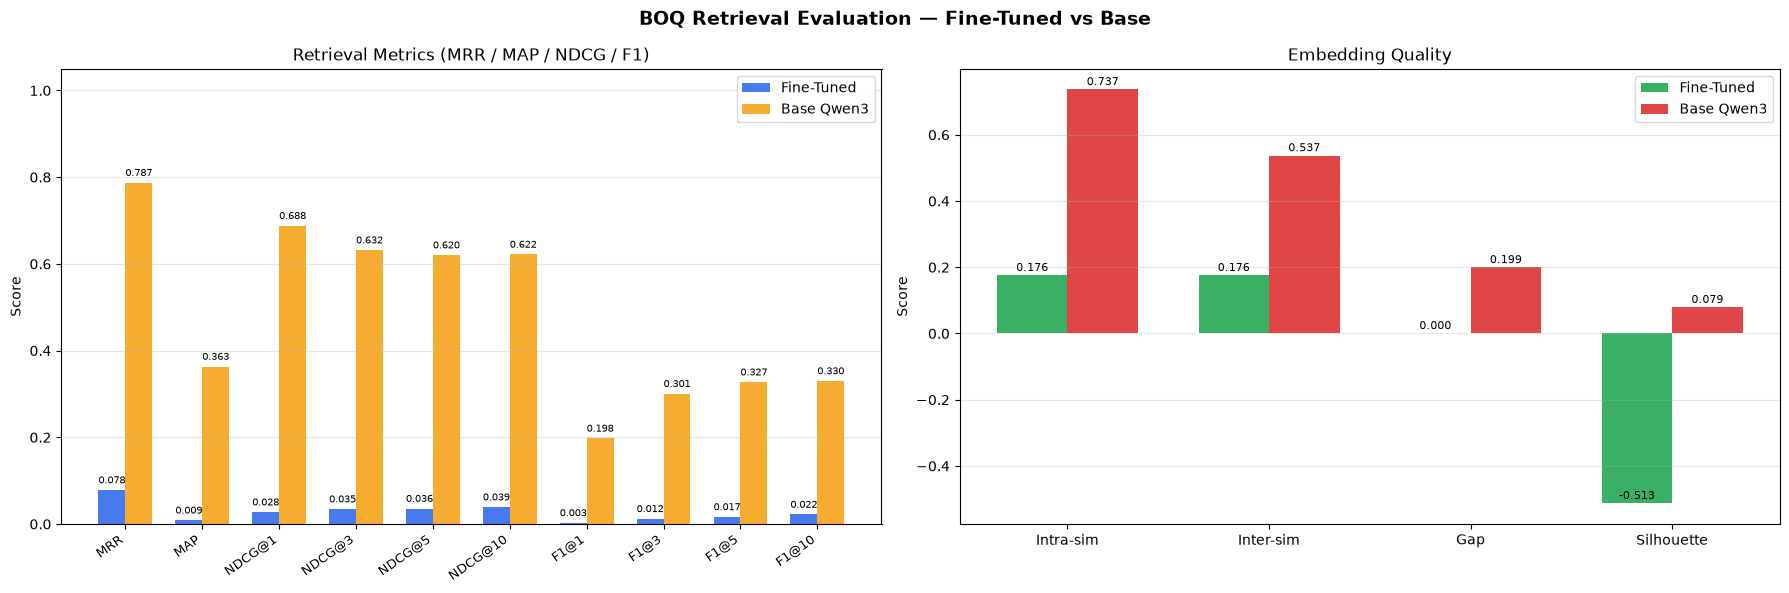

Chart saved → /content/drive/MyDrive/BOQ_FineTune_Neww/eval_results/eval_comparison.png
JSON report saved → /content/drive/MyDrive/BOQ_FineTune_Neww/eval_results/eval_report.json


In [11]:
# ================================================================
# CELL 12 — Side-by-Side Evaluation Report
#            HTML table + grouped bar charts + verdict
# ================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
from IPython.display import display, HTML

# ── HTML table helpers ──────────────────────────────────────────
def _color_val(v):
    if not isinstance(v, float) or np.isnan(v): return "#6b7280"
    return "#16a34a" if v >= 0.7 else ("#ca8a04" if v >= 0.4 else "#dc2626")

def _delta_html(a, b):
    if not (isinstance(a, float) and isinstance(b, float)): return "—"
    d = a - b
    if abs(d) < 1e-9: return "<span style='color:#6b7280'>= 0.0000</span>"
    c     = "#16a34a" if d > 0 else "#dc2626"
    arrow = "▲" if d > 0 else "▼"
    return f"<span style='color:{c};font-weight:700'>{arrow} {abs(d):.4f}</span>"

def val_td(v, highlight=True):
    if not isinstance(v, float) or np.isnan(v):
        return f"<td style='padding:6px 14px'>{v}</td>"
    col = _color_val(v) if highlight else "#1e293b"
    return (f"<td style='padding:6px 14px;color:{col};"            f"font-weight:600;text-align:right'>{v:.4f}</td>")

def build_html_table(rows, title, cols):
    th  = "".join(
        f"<th style='padding:6px 14px;background:#f1f5f9;"        f"border-bottom:2px solid #cbd5e1;text-align:left;"        f"font-size:11px;color:#475569'>{c}</th>" for c in cols)
    trs = ""
    for i, row in enumerate(rows):
        bg  = "#ffffff" if i % 2 == 0 else "#f8fafc"
        tds = "".join(
            f"<td style='padding:6px 14px;background:{bg}'><b>{row[0]}</b></td>"
            if j == 0
            else (val_td(v) + f"<!--bg:{bg}-->".replace("<!--bg:{bg}-->", "")).replace(
                "padding:6px 14px", f"padding:6px 14px;background:{bg}")
            if j < len(cols) - 1
            else f"<td style='padding:6px 14px;background:{bg};text-align:center'>{row[j]}</td>"
            for j, v in enumerate(row)
        )
        trs += f"<tr>{tds}</tr>"
    return (f"<div style='margin:16px 0;border:1px solid #e2e8f0;"            f"border-radius:10px;overflow:hidden;font-family:monospace'>"            f"<div style='padding:10px 16px;background:#e2e8f0;"            f"font-weight:700;font-size:13px;color:#0f172a'>{title}</div>"            f"<table style='width:100%;border-collapse:collapse;font-size:12px'>"            f"<thead><tr>{th}</tr></thead><tbody>{trs}</tbody></table></div>")

# ── Collect metric rows ─────────────────────────────────────────
ir_metric_keys = ["MRR", "MAP"] + [
    f"{m}@{k}" for k in TOP_K_LIST for m in ("Hit", "P", "R", "F1", "NDCG")]
ql_metric_keys = [
    "Avg cosine sim (same group)", "Avg cosine sim (diff group)",
    "Separation gap (delta)",      "Silhouette score"]

ir_rows = [[m, ft_ret.get(m, float("nan")), base_ret.get(m, float("nan")),
            _delta_html(ft_ret.get(m), base_ret.get(m))] for m in ir_metric_keys]
ql_rows = [[m, ft_qual.get(m, float("nan")), base_qual.get(m, float("nan")),
            _delta_html(ft_qual.get(m), base_qual.get(m))] for m in ql_metric_keys]

n_docs = len(stems_list)
n_q    = ft_ret["n_queries"]
n_grp  = ft_ret["n_groups"]

verdict_lines = []
for m in ["MRR", "MAP", f"NDCG@{max(TOP_K_LIST)}", f"F1@{max(TOP_K_LIST)}"]:
    ft_v, bv = ft_ret.get(m, 0), base_ret.get(m, 0)
    winner   = "Fine-Tuned" if ft_v > bv else ("Base" if bv > ft_v else "Tie")
    delta    = abs(ft_v - bv)
    verdict_lines.append(f"<b>{m}</b>: {winner} wins by {delta:.4f}")
verdict_html = "  |  ".join(verdict_lines)

display(HTML(
    "<div style='font-family:sans-serif;max-width:900px'>"    "<h2 style='color:#0f172a'>BOQ Retrieval: Fine-Tuned vs Base Qwen3-Embedding-0.6B</h2>"    f"<p style='color:#64748b;font-size:13px'>"    f"{n_docs} test BOQs | {n_grp} content groups | {n_q} evaluable queries | "    "FAISS IndexFlatIP | Asymmetric instruction encoding<br>"    f"<b>Verdict →</b> {verdict_html}</p>"    + build_html_table(ir_rows,
        "📊 Retrieval Metrics  (MRR · MAP · Hit@K · P@K · R@K · F1@K · NDCG@K)",
        ["Metric", "Fine-Tuned ▶", "Base Qwen3", "Delta (FT − Base)"])    + build_html_table(ql_rows,
        "🔍 Embedding Quality  (Intra/Inter Cosine · Separation · Silhouette)",
        ["Metric", "Fine-Tuned ▶", "Base Qwen3", "Delta (FT − Base)"])    + "</div>"
))

# ── Bar chart comparison ────────────────────────────────────────
plot_keys  = ["MRR", "MAP"] + [f"NDCG@{k}" for k in TOP_K_LIST] + [f"F1@{k}" for k in TOP_K_LIST]
ft_vals    = [ft_ret.get(k, 0)   for k in plot_keys]
base_vals  = [base_ret.get(k, 0) for k in plot_keys]

x     = np.arange(len(plot_keys))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("BOQ Retrieval Evaluation — Fine-Tuned vs Base", fontsize=14, fontweight="bold")

# Left: IR metrics bar chart
ax1 = axes[0]
b1  = ax1.bar(x - width/2, ft_vals,   width, label="Fine-Tuned", color="#2563eb", alpha=0.85)
b2  = ax1.bar(x + width/2, base_vals, width, label="Base Qwen3", color="#f59e0b", alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(plot_keys, rotation=35, ha="right", fontsize=9)
ax1.set_ylabel("Score"); ax1.set_ylim(0, 1.05)
ax1.set_title("Retrieval Metrics (MRR / MAP / NDCG / F1)")
ax1.legend(); ax1.grid(axis="y", alpha=0.3)
for bar in b1: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                        f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7)
for bar in b2: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                        f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7)

# Right: quality metrics
ql_keys2 = ["Avg cosine sim (same group)", "Avg cosine sim (diff group)",
             "Separation gap (delta)",      "Silhouette score"]
ql_ft   = [ft_qual.get(k, 0)   for k in ql_keys2]
ql_base = [base_qual.get(k, 0) for k in ql_keys2]
ql_labels = ["Intra-sim", "Inter-sim", "Gap", "Silhouette"]

ax2  = axes[1]
xq   = np.arange(len(ql_labels))
b3   = ax2.bar(xq - width/2, ql_ft,   width, label="Fine-Tuned", color="#16a34a", alpha=0.85)
b4   = ax2.bar(xq + width/2, ql_base, width, label="Base Qwen3", color="#dc2626", alpha=0.85)
ax2.set_xticks(xq); ax2.set_xticklabels(ql_labels, fontsize=10)
ax2.set_ylabel("Score"); ax2.set_title("Embedding Quality")
ax2.legend(); ax2.grid(axis="y", alpha=0.3)
for bar in b3: ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                        f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in b4: ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                        f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
chart_path = EVAL_DIR / "eval_comparison.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved → {chart_path}")

# ── Save JSON report ────────────────────────────────────────────
report = {
    "n_test_docs":  n_docs,
    "n_groups":     n_grp,
    "n_queries":    n_q,
    "fine_tuned": {**ft_ret, **ft_qual},
    "base":        {**base_ret, **base_qual},
}
json_path = EVAL_DIR / "eval_report.json"
with open(json_path, "w") as f:
    json.dump(report, f, indent=2, default=str)
print(f"JSON report saved → {json_path}")


Per-group NDCG@10  (sorted by Fine-Tuned score desc)

Grp   Docs   FT NDCG  Base NDCG     Delta  Winner        Top keywords
-----------------------------------------------------------------------------------------------
  49     2    0.1934     0.4732   -0.2798  Base ✓        ton, salvage, section, havells
  51     2    0.1934     0.7153   -0.5219  Base ✓        ton, m40, matt, 63mm
  0     58    0.1293     0.8636   -0.7343  Base ✓        paint, ton, based, coats
  55     6    0.0922     0.5841   -0.4919  Base ✓        floors, trench, circuits, pipes
  21     3    0.0791     0.5130   -0.4340  Base ✓        floors, circuits, piles, strata
  81     4    0.0740     0.8263   -0.7523  Base ✓        circuits, shutters, pipes, invert
  67     4    0.0678     0.5072   -0.4394  Base ✓        paint, color, 20m, 47mm
  12     3    0.0645     0.5990   -0.5345  Base ✓        concealed, fe415, substructure, agricultural
  9      4    0.0587     0.6760   -0.6173  Base ✓        paint, inverter, star, 

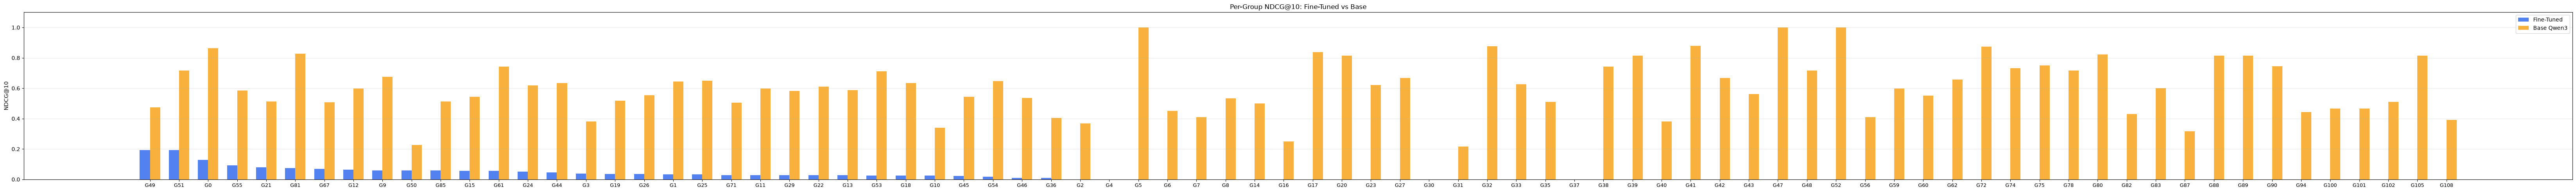

Per-group chart saved → /content/drive/MyDrive/BOQ_FineTune_Neww/eval_results/per_group_ndcg_10.png


In [12]:
# ================================================================
# CELL 13 — Per-Group NDCG@10 Breakdown
#            Shows which BOQ categories improved vs degraded.
# ================================================================
from collections import defaultdict

def per_group_ndcg(query_emb, corpus_index, cluster_ids, k=10):
    """Return dict: group_id → NDCG@k."""
    cluster_ids = np.array(cluster_ids)
    n     = len(cluster_ids)
    kmax  = k + 1
    _, idx_mat = faiss_retrieve(query_emb, corpus_index, kmax)

    R     = (cluster_ids[:, None] == cluster_ids[None, :]).astype(np.float32)
    np.fill_diagonal(R, 0.0)
    n_rel = R.sum(axis=1)
    log2d = np.log2(np.arange(2, k + 2))

    group_ndcg = defaultdict(list)
    for qi in range(n):
        if n_rel[qi] == 0:
            continue
        rids  = [c for c in idx_mat[qi] if c != qi and c >= 0][:k]
        rel_v = np.array([R[qi, c] for c in rids] + [0.0] * (k - len(rids)))
        dcg   = float((rel_v / log2d[:k]).sum())
        idl_n = int(min(n_rel[qi], k))
        idl   = float((1.0 / log2d[:idl_n]).sum()) if idl_n > 0 else 0.0
        ndcg  = dcg / idl if idl > 0 else 0.0
        group_ndcg[doc_cluster[stems_list[qi]]].append(ndcg)

    return {g: float(np.mean(v)) for g, v in group_ndcg.items()}

K_BREAKDOWN = 10
ft_grp_ndcg   = per_group_ndcg(ft_query_emb,   ft_corpus_index,   cluster_ids, K_BREAKDOWN)
base_grp_ndcg = per_group_ndcg(base_query_emb, base_corpus_index, cluster_ids, K_BREAKDOWN)

all_groups = sorted(set(ft_grp_ndcg) | set(base_grp_ndcg))

print(f"Per-group NDCG@{K_BREAKDOWN}  (sorted by Fine-Tuned score desc)\n")
print(f"{'Grp':<5} {'Docs':>4}  {'FT NDCG':>8}  {'Base NDCG':>9}  "      f"{'Delta':>8}  {'Winner':<12}  Top keywords")
print("-" * 95)

rows_sorted = sorted(all_groups,
                     key=lambda g: ft_grp_ndcg.get(g, 0), reverse=True)
for g in rows_sorted:
    ft_v   = ft_grp_ndcg.get(g, 0.0)
    base_v = base_grp_ndcg.get(g, 0.0)
    delta  = ft_v - base_v
    winner = "Fine-Tuned ✓" if delta > 1e-4 else ("Base ✓" if delta < -1e-4 else "Tie")
    mems   = cluster_members[g]
    common = Counter()
    for m in mems: common.update(doc_keywords.get(m, [])[:5])
    kw_sig = ", ".join(k for k, _ in common.most_common(4))
    print(f"  {g:<3} {len(mems):>4}  {ft_v:>8.4f}  {base_v:>9.4f}  "          f"{delta:>+8.4f}  {winner:<12}  {kw_sig}")

# ── Mini bar chart ──────────────────────────────────────────────
if len(rows_sorted) > 0:
    labels_ = [f"G{g}" for g in rows_sorted]
    ft_v_   = [ft_grp_ndcg.get(g, 0) for g in rows_sorted]
    ba_v_   = [base_grp_ndcg.get(g, 0) for g in rows_sorted]
    x_  = np.arange(len(labels_))
    w_  = 0.35
    fig2, ax = plt.subplots(figsize=(max(10, len(labels_)*0.8+2), 5))
    ax.bar(x_ - w_/2, ft_v_, w_, label="Fine-Tuned", color="#2563eb", alpha=0.8)
    ax.bar(x_ + w_/2, ba_v_, w_, label="Base Qwen3", color="#f59e0b", alpha=0.8)
    ax.set_xticks(x_); ax.set_xticklabels(labels_, fontsize=9)
    ax.set_ylim(0, 1.1); ax.set_ylabel(f"NDCG@{K_BREAKDOWN}")
    ax.set_title(f"Per-Group NDCG@{K_BREAKDOWN}: Fine-Tuned vs Base")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    pg_path = EVAL_DIR / f"per_group_ndcg_{K_BREAKDOWN}.png"
    plt.savefig(pg_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Per-group chart saved → {pg_path}")


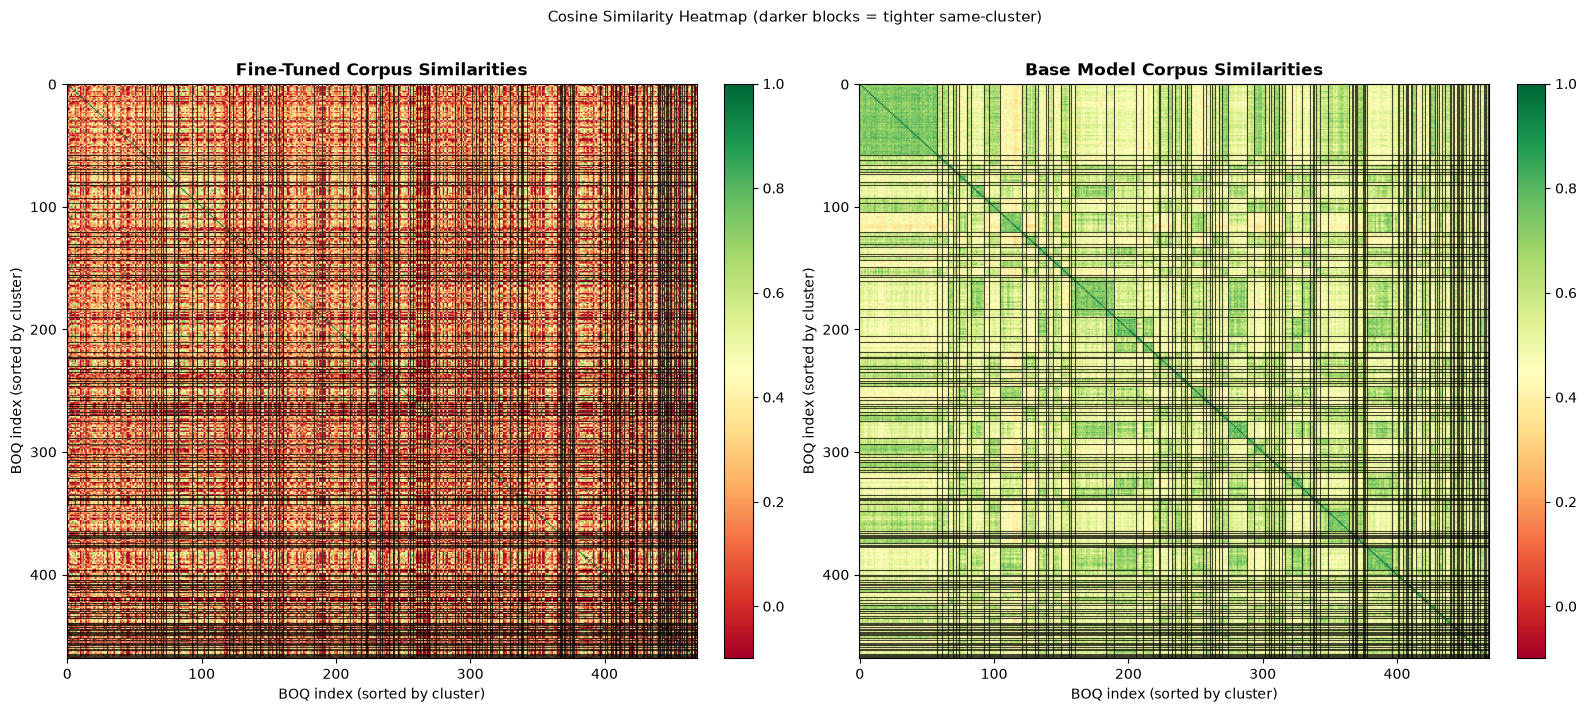

Heatmap saved → /content/drive/MyDrive/BOQ_FineTune_Neww/eval_results/heatmap_cosine_similarity.png


In [13]:
# ================================================================
# CELL 14 — Cosine Similarity Heatmaps
#            Visual: how tight are the clusters in each model?
# ================================================================
import matplotlib.pyplot as plt

# Sort stems by cluster for cleaner diagonal block pattern
sorted_stems = sorted(stems_list, key=lambda s: doc_cluster[s])
sort_idx     = [stems_list.index(s) for s in sorted_stems]

def sorted_sim_matrix(emb):
    E = emb[sort_idx]
    return (E @ E.T)

ft_sim   = sorted_sim_matrix(ft_corpus_emb)
base_sim = sorted_sim_matrix(base_corpus_emb)

# Cluster boundary lines
boundaries = []
prev = doc_cluster[sorted_stems[0]]
for i, s in enumerate(sorted_stems):
    if doc_cluster[s] != prev:
        boundaries.append(i - 0.5)
        prev = doc_cluster[s]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, mat, title in [
        (axes[0], ft_sim,   "Fine-Tuned Corpus Similarities"),
        (axes[1], base_sim, "Base Model Corpus Similarities")]:
    im = ax.imshow(mat, cmap="RdYlGn", vmin=-0.1, vmax=1.0, aspect="auto")
    for b in boundaries:
        ax.axhline(b, color="black", lw=0.8, alpha=0.7)
        ax.axvline(b, color="black", lw=0.8, alpha=0.7)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("BOQ index (sorted by cluster)")
    ax.set_ylabel("BOQ index (sorted by cluster)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Cosine Similarity Heatmap (darker blocks = tighter same-cluster)",
             fontsize=11, y=1.01)
plt.tight_layout()
hm_path = EVAL_DIR / "heatmap_cosine_similarity.png"
plt.savefig(hm_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Heatmap saved → {hm_path}")


In [15]:
# ================================================================
# CELL 15 — Single-Query Demo
#            Upload any BOQ PDF → encode → search both FAISS
#            indices → show Top-10 ranked results for each model.
# ================================================================
from google.colab import files as colab_files
from pathlib import Path

print("Upload a BOQ PDF to query (can be the same test set or a new file) ...")
q_uploaded = colab_files.upload()

if not q_uploaded:
    print("No file uploaded.")
else:
    q_fname  = list(q_uploaded.keys())[0]
    q_path   = f"/content/{q_fname}"
    Path(q_path).write_bytes(q_uploaded[q_fname])
    q_stem   = Path(q_fname).stem

    print(f"\nExtracting text from: {q_fname}")
    q_raw  = smart_extract(q_path, verbose=True)
    q_descs = extract_boq_descriptions(q_raw)

    if not q_descs:
        print("⚠  No BOQ descriptions found. Try a different PDF.")
    else:
        print(f"  {len(q_descs)} description lines extracted.")

        # ── Build smart anchor for the query ───────────────────
        if q_stem in doc_anchors:
            q_anchor = doc_anchors[q_stem]
            print(f"  Using cached anchor for: {q_stem}")
        else:
            # Fit on-the-fly using existing tfidf vectorizer
            _q_vec   = tfidf.transform([" ".join(q_descs)]).toarray()[0]
            q_anchor = make_smart_anchor(q_stem, q_descs, row=_q_vec)

        q_instr = QUERY_INSTRUCTION + q_anchor

        def _encode_query(model_path: str, is_base: bool = False) -> np.ndarray:
            mdl = SentenceTransformer(model_path, trust_remote_code=True)
            mdl.max_seq_length = MAX_SEQ_LEN
            if is_base:
                try:
                    mdl[0].tokenizer.padding_side   = "left"
                    mdl[1].pooling_mode_lasttoken   = True
                    mdl[1].pooling_mode_mean_tokens = False
                except Exception: pass
            emb = mdl.encode([q_instr], normalize_embeddings=True,
                             convert_to_numpy=True)
            del mdl; release_gpu()
            return emb.astype(np.float32)

        print("\nEncoding query with FINE-TUNED model ...")
        q_ft   = _encode_query(FT_MODEL_DIR)
        print("Encoding query with BASE model ...")
        q_base = _encode_query(BASE_MODEL_NAME, is_base=True)

        def show_top10_faiss(q_emb, index, corpus_emb, label):
            """Search FAISS, display top-10 results, skip self if present."""
            K_SHOW = 12
            scores, idx_arr = index.search(q_emb, K_SHOW)
            scores, idx_arr = scores[0], idx_arr[0]

            print(f"\n{'='*68}")
            print(f"  TOP 10  [{label}]   query: {q_fname}")
            print(f"{'='*68}")
            print(f"  {'Rank':<5} {'Score':>7}  {'Group':<6}  Document")
            print(f"  {'----':<5} {'-----':>7}  {'-----':<6}  --------")

            rank = 1
            for i, (sc, cid) in enumerate(zip(scores, idx_arr)):
                if cid < 0: continue
                s   = stems_list[cid]
                if s == q_stem:   # skip self-match
                    continue
                grp = doc_cluster.get(s, "?")
                kws = " | ".join(doc_keywords.get(s, [])[:2])
                print(f"  {rank:<5} {sc:>7.4f}  {grp:<6}  {s}  [{kws}]")
                rank += 1
                if rank > 10: break

        show_top10_faiss(q_ft,   ft_corpus_index,   ft_corpus_emb,   "FINE-TUNED")
        show_top10_faiss(q_base, base_corpus_index, base_corpus_emb, "BASE Qwen3")

        # ── Show query's own top keywords ────────────────────────
        print(f"\nQuery BOQ — top domain keywords:")
        if q_stem in doc_label:
            print(f"  {doc_label[q_stem]}")
        else:
            _rv  = tfidf.transform([" ".join(q_descs)]).toarray()[0]
            _kws = [feature_names[j] for j in np.argsort(-_rv)[:6] if _rv[j] > 0]
            print(f"  {' | '.join(_kws)}")

Upload a BOQ PDF to query (can be the same test set or a new file) ...


Saving BOQ_0410_Multi-Storey_Car_Parking.pdf to BOQ_0410_Multi-Storey_Car_Parking.pdf

Extracting text from: BOQ_0410_Multi-Storey_Car_Parking.pdf
  [pdfplumber] 5 pages, 14328 chars
  Using pdfplumber
  148 description lines extracted.

Encoding query with FINE-TUNED model ...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] Qwen3Model LOAD REPORT from: /content/drive/MyDrive/BOQ_FineTune_Neww/best_model
Key                                                    | Status     | 
-------------------------------------------------------+------------+-
layers.{0...27}.self_attn.o_proj.lora_A.default.weight | UNEXPECTED | 
layers.{0...27}.self_attn.q_proj.lora_B.default.weight | UNEXPECTED | 
layers.{0...27}.self_attn.q_proj.base_layer.weight     | UNEXPECTED | 
layers.{0...27}.self_attn.v_proj.lora_A.default.weight | UNEXPECTED | 
layers.{0...27}.self_attn.q_proj.lora_A.default.weight | UNEXPECTED | 
layers.{0...27}.self_attn.k_proj.lora_B.default.weight | UNEXPECTED | 
layers.{0...27}.self_attn.k_proj.lora_A.default.weight | UNEXPECTED | 
layers.{0...27}.self_attn.o_proj.lora_B.default.weight | UNEXPECTED | 
layers.{0...27}.self_attn.v_proj.base_layer.weight     | UNEXPECTED | 
layers.{0...27}.self_attn.k_proj.base_layer.weight     | UNEXPECTED | 
layers.{0...27}.self_attn.o_proj.base_layer.weight  

Encoding query with BASE model ...


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]


  TOP 10  [FINE-TUNED]   query: BOQ_0410_Multi-Storey_Car_Parking.pdf
  Rank    Score  Group   Document
  ----    -----  -----   --------
  1      0.4486  60      BOQ_0461_Sewage_Treatment_Facility  [galvalume | 4mm]
  2      0.4363  109     BOQ_0361_Multi-Storey_Car_Parking  [mosquito | break]
  3      0.4022  58      BOQ_0272_Luxury_Hotel_and_Resort  [pipes | floors]
  4      0.3965  0       BOQ_0342_Pharmaceutical_Manufacturing_U  [paint | 5mm]
  5      0.3887  100     BOQ_0470_Affordable_Housing_Scheme  [soft | paint]
  6      0.3434  67      BOQ_0337_Port_&_Harbor_Development  [hard | paint]
  7      0.3411  19      BOQ_0459_Hospital_&_Healthcare_Facility  [excluding | mosquito]
  8      0.3333  48      BOQ_0475_Sports_Stadium_Upgrade  [cages | corridors]
  9      0.3309  25      BOQ_0495_Cold_Storage_Warehouse  [shutters | pipes]
  10     0.3267  55      BOQ_0340_Industrial_Manufacturing_Uni  [floors | slurry]

  TOP 10  [BASE Qwen3]   query: BOQ_0410_Multi-Storey_Car_Parking.pd

## 📖 How to Read This Report

| Metric | What it measures |
|--------|-----------------|
| **MRR** | Mean Reciprocal Rank — how high the *first* relevant doc appears (1.0 = always rank 1) |
| **MAP** | Mean Average Precision — area under the precision-recall curve |
| **Hit@K** | % of queries where at least 1 relevant doc appears in top K |
| **P@K** | Precision at K — fraction of top-K results that are relevant |
| **R@K** | Recall at K — fraction of all relevant docs captured in top K |
| **F1@K** | Harmonic mean of P@K and R@K |
| **NDCG@K** | Normalised Discounted Cumulative Gain — rewards relevant docs ranked higher |
| **Intra-class sim** | Avg cosine similarity between docs in the *same* content group (higher = better) |
| **Inter-class sim** | Avg cosine similarity between docs in *different* groups (lower = better) |
| **Separation gap** | Intra minus Inter — fine-tuning should widen this gap |
| **Silhouette** | Clustering quality −1 to +1 — higher = tighter, better-separated groups |

### Ground Truth
Groups are built by **agglomerative clustering** of content-driven smart anchors — no filenames, no manual labels. Two BOQs are "relevant" to each other if they fall in the same content cluster.

### FAISS Index
`IndexFlatIP` — exact inner-product search on L2-normalised embeddings = exact cosine similarity.  
Indices are saved to Google Drive so you can reload without re-encoding.

### Interpreting Results
- Fine-tuned model should show **higher intra-class sim, lower inter-class sim** (wider separation gap)  
- NDCG and MRR improvements show the model retrieves same-type BOQs earlier in the ranked list  
- Small test sets (< 20 BOQs) will have noisy estimates — use 30+ for reliable numbers
